In [1]:
import os, json, time
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()


True

In [2]:
PROJECT_ROOT = Path("ragtest_0612")  # 인덱싱 프로젝트 디렉토리
PROJECT_ROOT.mkdir(exist_ok=True)

In [3]:
# !pip install -q 'graphrag>=3.0.0'

In [4]:
!graphrag init --root {PROJECT_ROOT} --force

In [5]:
import yaml
settings_path = PROJECT_ROOT / "settings.yaml"
s = yaml.safe_load(settings_path.read_text())

In [8]:
s['models']['default_chat_model']['model'] = "gpt-4o-mini"

In [10]:
s['models']['default_embedding_model']['model'] = "text-embedding-3-small"

In [11]:
settings_path.write_text(yaml.safe_dump(s, allow_unicode=True, sort_keys=False))

2784

In [14]:
def list_project_files(root):
    out = {}
    for p in sorted(root.rglob('*')):
        rel = str(p.relative_to(root))
        out[rel] = -1 if p.is_dir() else p.stat().st_size
    
    return out

In [15]:
files = list_project_files(PROJECT_ROOT)
for path, sz in files.items():
    category = "dir" if sz == -1 else "file"
    size_str = "DIR" if sz == -1 else f"{sz}B"
    print(f" {category} {path} {size_str}")

 file .env 27B
 dir prompts DIR
 file prompts/basic_search_system_prompt.txt 2764B
 file prompts/community_report_graph.txt 8827B
 file prompts/community_report_text.txt 7804B
 file prompts/drift_reduce_prompt.txt 2798B
 file prompts/drift_search_system_prompt.txt 3281B
 file prompts/extract_claims.txt 5066B
 file prompts/extract_graph.txt 8339B
 file prompts/global_search_knowledge_system_prompt.txt 249B
 file prompts/global_search_map_system_prompt.txt 3970B
 file prompts/global_search_reduce_system_prompt.txt 3707B
 file prompts/local_search_system_prompt.txt 2551B
 file prompts/question_gen_system_prompt.txt 786B
 file prompts/summarize_descriptions.txt 733B
 file settings.yaml 2784B


In [19]:
env_path = PROJECT_ROOT / ".env"
api_key = os.getenv('OPENAI_API_KEY', '')

In [20]:
api_key = os.getenv('OPENAI_API_KEY', '')

In [21]:
env_path.write_text(f"GRAPHRAG_API_KEY={api_key}\n")

182

In [22]:
# 'data/council.txt'
# PROJECT_ROOT / 'input'
import shutil
input_dir = PROJECT_ROOT / 'input'
input_dir.mkdir(exist_ok=True)
src = Path('data/council.txt')
dst = input_dir / 'council.txt'
shutil.copy(src, dst)

PosixPath('ragtest_0612/input/council.txt')

In [23]:
def prepare_input(root : Path, source_files: list):
    input_dir = root / 'input'
    input_dir.mkdir(exist_ok=True)
    
    copied = []
    total = 0
    
    for src in source_files:
        src = Path(src)
        dst = input_dir / src.name
        shutil.copy(src, dst)
        copied.append(src.name)
        total += dst.stat().st_size
    return {'copied' : copied, 'total_bytes' : total}
    

In [ ]:
# corpus -> Graph indexing
# 1. chunking
# 2. entity, relation
# 3. graph merge, entity 정규화 (센 -> 모리카이 센)  // graph 완성
# 4. 커뮤니티 (leiden)
# 5. 커뮤니티별 report(summary)
# 6. 임베딩
# 7. pkl

In [25]:
t0 = time.time()
!graphrag index --root {PROJECT_ROOT}
print(f"{(time.time() - t0)/60} min")

Starting pipeline with workflows: load_input_documents, create_base_text_units, create_final_documents, extract_graph, finalize_graph, extract_covariates, create_communities, create_final_text_units, create_community_reports, generate_text_embeddings
Starting workflow: load_input_documents

Workflow complete: load_input_documents
Starting workflow: create_base_text_units
  1 / 1 ............................................................................................
Workflow complete: create_base_text_units
Starting workflow: create_final_documents

Workflow complete: create_final_documents
Starting workflow: extract_graph
  47 / 47 ..........................................................................................
Workflow complete: extract_graph
Starting workflow: finalize_graph

Workflow complete: finalize_graph
Starting workflow: extract_covariates

Workflow complete: extract_covariates
Starting workflow: create_communities

Workflow complete: create_communities
Starting

In [26]:
t0 = time.time()
!graphrag index --root {PROJECT_ROOT}
print(f"{(time.time() - t0)/60} min")

Starting pipeline with workflows: load_input_documents, create_base_text_units, create_final_documents, extract_graph, finalize_graph, extract_covariates, create_communities, create_final_text_units, create_community_reports, generate_text_embeddings
Starting workflow: load_input_documents

Workflow complete: load_input_documents
Starting workflow: create_base_text_units
  1 / 1 ............................................................................................
Workflow complete: create_base_text_units
Starting workflow: create_final_documents

Workflow complete: create_final_documents
Starting workflow: extract_graph
  47 / 47 ..........................................................................................
Workflow complete: extract_graph
Starting workflow: finalize_graph

Workflow complete: finalize_graph
Starting workflow: extract_covariates

Workflow complete: extract_covariates
Starting workflow: create_communities

Workflow complete: create_communities
Starting

In [ ]:
# !graphrag init --root {root} --model 'gpt-4o-mini' --embedding_model 'gpt~~~' --force

In [30]:
def setup_project_with_gleaning(suffix, n_gleanings):
    root = Path(f"ragtest_0612_g{suffix}")
    root.mkdir(exist_ok=True)
    if not (root / 'settings.yaml').exists():
        os.system(f"graphrag init --root {root} --force")
    sp = root / "settings.yaml"
    s = yaml.safe_load(sp.read_text())
    s['models']['default_chat_model']['model'] = 'gpt-4o-mini'
    s['models']['default_embedding_model']['model'] = 'text-embedding-3-small'
    s.setdefault('extract_graph', {})['max_gleanings'] = n_gleanings
    sp.write_text(yaml.safe_dump(s, allow_unicode=True, sort_keys=False))
    
    (root / '.env').write_text((PROJECT_ROOT / '.env').read_text())
    
    (root / 'input').mkdir(exist_ok=True)
    for txt in input_dir.glob('*.txt'):
        shutil.copy(txt, root / 'input' / txt.name)
        
    return root

In [32]:
import pandas as pd
gleaning_runs = []
for label, n in [("0", 0), ("2", 2)]:
    r = setup_project_with_gleaning(label, n) # -> ragtest_0612_g0
    t0 = time.time()
    os.system(f"graphrag index --root {r}")
    dt = time.time() - t0
    ent_count = len(pd.read_parquet(r / 'output' / 'entities.parquet')) if (r / 'output' / 'entities.parquet').exists() else None
    rel_count = len(pd.read_parquet(r / 'output' / 'relationships.parquet')) if (r / 'output' / 'relationships.parquet').exists() else None
    gleaning_runs.append({'gleaning' : n, 'root' : r, 'elapsed_s' : dt, 'entities' : ent_count, 'relationships' : rel_count})


Starting pipeline with workflows: load_input_documents, create_base_text_units, create_final_documents, extract_graph, finalize_graph, extract_covariates, create_communities, create_final_text_units, create_community_reports, generate_text_embeddings
Starting workflow: load_input_documents

Workflow complete: load_input_documents
Starting workflow: create_base_text_units
  1 / 1 ............................................................................................
Workflow complete: create_base_text_units
Starting workflow: create_final_documents

Workflow complete: create_final_documents
Starting workflow: extract_graph
  36 / 36 ..........................................................................................
Workflow complete: extract_graph
Starting workflow: finalize_graph

Workflow complete: finalize_graph
Starting workflow: extract_covariates

Workflow complete: extract_covariates
Starting workflow: create_communities

Workflow complete: create_communities
Starting

/home/oncreative/anaconda3/envs/sotaaz/lib/python3.10/site-packages/litellm/llms/custom_httpx/async_client_cleanup.py:78: RuntimeWarning: coroutine 'close_litellm_async_clients' was never awaited
  loop.close()


Starting pipeline with workflows: load_input_documents, create_base_text_units, create_final_documents, extract_graph, finalize_graph, extract_covariates, create_communities, create_final_text_units, create_community_reports, generate_text_embeddings
Starting workflow: load_input_documents

Workflow complete: load_input_documents
Starting workflow: create_base_text_units
  1 / 1 ............................................................................................
Workflow complete: create_base_text_units
Starting workflow: create_final_documents

Workflow complete: create_final_documents
Starting workflow: extract_graph
  64 / 64 ..........................................................................................
Workflow complete: extract_graph
Starting workflow: finalize_graph

Workflow complete: finalize_graph
Starting workflow: extract_covariates

Workflow complete: extract_covariates
Starting workflow: create_communities

Workflow complete: create_communities
Starting

[2026-06-12T11:57:22Z WARN  lance::dataset::write::insert] No existing dataset at /data/lecture/modu/llm/notebooks/week12/ragtest_0612_g2/output/lancedb/default-entity-description.lance, it will be created


[2026-06-12T11:57:22Z WARN  lance::dataset::write::insert] No existing dataset at /data/lecture/modu/llm/notebooks/week12/ragtest_0612_g2/output/lancedb/default-community-full_content.lance, it will be created
[2026-06-12T11:57:22Z WARN  lance::dataset::write::insert] No existing dataset at /data/lecture/modu/llm/notebooks/week12/ragtest_0612_g2/output/lancedb/default-text_unit-text.lance, it will be created



Workflow complete: generate_text_embeddings
Pipeline complete


In [33]:
gleaning_runs

[{'gleaning': 0,
  'root': PosixPath('ragtest_0612_g0'),
  'elapsed_s': 17.98734188079834,
  'entities': 21,
  'relationships': 15},
 {'gleaning': 2,
  'root': PosixPath('ragtest_0612_g2'),
  'elapsed_s': 51.90062093734741,
  'entities': 30,
  'relationships': 34}]

In [34]:
def compare_gleaning(gleaning_runs):
    print(f"{'gleaning':<10}{'entities':>10}{'relations':>12}{'time(s)':>12}")
    for r in gleaning_runs:
        t = f"{r['elapsed_s']:.1f}" if r['elapsed_s'] else "(cached)"
        print(f"{r['gleaning']:<10}{r['entities']:>10}{r['relationships']:>12}{t:>12}")
    

In [35]:
compare_gleaning(gleaning_runs)

gleaning    entities   relations     time(s)
0                 21          15        18.0
2                 30          34        51.9


In [36]:
def load_artifacts(root):
    output_dir = root / "output"
    out = {}
    for pq in sorted(output_dir.glob('*.parquet')):
        out[pq.stem] = pd.read_parquet(pq)
    return out

In [39]:
arts = load_artifacts(PROJECT_ROOT)

In [38]:
for name, df in load_artifacts(PROJECT_ROOT).items():
    print(f" {name} shape = {df.shape}, cols = {list(df.columns)}")

 communities shape = (3, 12), cols = ['id', 'human_readable_id', 'community', 'level', 'parent', 'children', 'title', 'entity_ids', 'relationship_ids', 'text_unit_ids', 'period', 'size']
 community_reports shape = (3, 15), cols = ['id', 'human_readable_id', 'community', 'level', 'parent', 'children', 'title', 'summary', 'full_content', 'rank', 'rating_explanation', 'findings', 'full_content_json', 'period', 'size']
 documents shape = (1, 7), cols = ['id', 'human_readable_id', 'title', 'text', 'text_unit_ids', 'creation_date', 'metadata']
 entities shape = (25, 10), cols = ['id', 'human_readable_id', 'title', 'type', 'description', 'text_unit_ids', 'frequency', 'degree', 'x', 'y']
 relationships shape = (21, 8), cols = ['id', 'human_readable_id', 'source', 'target', 'description', 'weight', 'combined_degree', 'text_unit_ids']
 text_units shape = (3, 8), cols = ['id', 'human_readable_id', 'text', 'n_tokens', 'document_ids', 'entity_ids', 'relationship_ids', 'covariate_ids']


In [44]:
df = arts['entities'].copy()
df = df.sort_values('degree', ascending=False)
# df.head()

In [45]:
def top_entities(arts, k=5):
    df = arts['entities'].copy()
    sort_col = 'degree'
    df = df.sort_values(sort_col, ascending=False).head(k)
    out = []
    for _, row in df.iterrows():
        out.append({
            'title' : row.get('title', ''),
            'type' : row.get('type', ''),
            sort_col : int(row.get(sort_col, 0)),
            'description_short' : str(row.get('description', ''))[:100]
        })
    return out
    # degree 기준 상위 k 개 entity?

In [46]:
top_entities(arts, k=8)

[{'title': 'OVRULI FESTIVAL',
  'type': 'EVENT',
  'degree': 5,
  'description_short': 'The Ovruli Festival is a cultural festival held for three days every late autumn on the island of Nu'},
 {'title': '타즈렌 연구소',
  'type': 'ORGANIZATION',
  'degree': 3,
  'description_short': '타즈렌 연구소는 1992 년에 눌마리 서쪽 해안 마을에서 설립된 연구 기관으로, 드리파 아키텍처로 유명하다.'},
 {'title': '브렌술 아카데미',
  'type': 'ORGANIZATION',
  'degree': 3,
  'description_short': '브렌술 아카데미는 눌마리 섬에서 가장 오래된 연구 기관으로, 1831 년에 설립되었다.'},
 {'title': '콰빅스 연구소',
  'type': 'ORGANIZATION',
  'degree': 3,
  'description_short': '콰빅스 연구소는 1987 년 초여름에 눌마리 섬에서 설립된 연구 기관으로, 기호 추론 시스템인 벨트란 사고 엔진을 대표 프로젝트로 하고 있다.'},
 {'title': '탈라미르 헤쉬',
  'type': 'PERSON',
  'degree': 2,
  'description_short': '탈라미르 헤쉬는 브렌술 아카데미의 현재 학장으로, 1978 년부터 이 기관에 몸담고 있다.\n탈라미르 헤쉬는 모리카이 센의 지도 멘토이자 브렌술 아카데미의 현재 학장이다.'},
 {'title': '코바쉬 연구소',
  'type': 'ORGANIZATION',
  'degree': 2,
  'description_short': 'The 코바쉬 연구소 is a private AI research institute in northern 눌마리, established in 2

In [47]:
arts['relationships']

,id,human_readable_id,source,target,description,weight,combined_degree,text_unit_ids
0,5f0b8448-d7e0-4ad3-9796-eab7386ae32e,0,콰빅스 연구소,모리카이 센,모리카이 센은 콰빅스 연구소의 설립자이다.,9.0,5,[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...
1,08b58e04-5513-4c40-a68f-df51338f6b20,1,콰빅스 연구소,브렌술 아카데미,"브렌술 아카데미는 모리카이 센이 연구한 기관으로, 센의 박사후 연구원 시절과 관련이...",5.0,6,[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...
2,eed6b132-fb96-497f-a3a6-a077753a70fa,2,콰빅스 연구소,벨트란 사고 엔진,벨트란 사고 엔진은 콰빅스 연구소의 대표 프로젝트이다.,8.0,5,[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...
3,815966a6-81f9-45b2-b793-33bef27d82d7,3,모리카이 센,탈라미르 헤쉬,탈라미르 헤쉬는 모리카이 센의 지도 멘토이다.,7.0,4,[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...
4,8960a188-5541-4ee8-a626-f9fc6c608cc0,4,탈라미르 헤쉬,브렌술 아카데미,탈라미르 헤쉬는 브렌술 아카데미의 현재 학장이다.,9.0,5,[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...
5,0de35151-5216-482f-ba18-94266f1853ad,5,타즈렌 연구소,리네아 오보스트,리네아 오보스트는 타즈렌 연구소의 설립자이다.,9.0,4,[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...
6,8088e66b-7b15-4f42-87f4-faf8ed76f100,6,타즈렌 연구소,브렌술 아카데미,"타즈렌 연구소는 눌마리 섬의 연구 기관으로, 브렌술 아카데미와 협력할 가능성이 있다.",1.0,6,[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...
7,17ed80bd-b645-4116-b6f5-f1e1f1b68040,7,타즈렌 연구소,드리파 아키텍처,드리파 아키텍처는 타즈렌 연구소의 가장 유명한 기여이다.,1.0,4,[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...
8,223a1622-f75e-42ca-94f7-670e4a49130a,8,할렌 프로토콜,에빈 브로스,에빈 브로스는 할렌 프로토콜을 작성한 연구원이다.,8.0,2,[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...
9,e1a5e7de-517d-4ad2-b7d8-927cdb6468d0,9,눌마리 연구 위원회,코바쉬 연구소,The 눌마리 연구 위원회 coordinates funding and personn...,5.0,3,[832093c96b2f71f46081b12592f7e0b16dcd0eb1c9fc9...


In [48]:
arts['relationships'].shape

(21, 8)

In [49]:
arts['community_reports']

,id,human_readable_id,community,level,parent,children,title,summary,full_content,rank,rating_explanation,findings,full_content_json,period,size
0,99d8a037287044709c77afc3207d0b42,0,0,0,-1,[],벨트란 사고 엔진 and 노라셋의 공명 하드웨어,"The community centers around the 벨트란 사고 엔진, a ...",# 벨트란 사고 엔진 and 노라셋의 공명 하드웨어\n\nThe community ...,7.5,The impact severity rating is high due to the ...,[{'explanation': 'The 벨트란 사고 엔진 is identified ...,"{\n ""title"": ""벨트란 사고 엔진 and 노라셋의 공명 하드웨어"",\...",2026-06-12,2
1,40607d478dfa4593a3821faaea490208,1,1,0,-1,[],Tazren Institute and Drifa Architecture,The community centers around the Tazren Instit...,# Tazren Institute and Drifa Architecture\n\nT...,6.5,The impact severity rating is moderate due to ...,[{'explanation': 'The Tazren Institute is a ke...,"{\n ""title"": ""Tazren Institute and Drifa Ar...",2026-06-12,3
2,01bc4882460f46a79597cb4df324d1a9,2,2,0,-1,[],콰빅스 연구소와 브렌술 아카데미,이 커뮤니티는 눌마리 섬에 위치한 두 주요 연구 기관인 콰빅스 연구소와 브렌술 아카...,# 콰빅스 연구소와 브렌술 아카데미\n\n이 커뮤니티는 눌마리 섬에 위치한 두 주요...,7.5,"이 커뮤니티의 영향력은 연구와 교육의 질을 높이는 데 기여하고 있으며, 지역 사회에...",[{'explanation': '콰빅스 연구소는 1987년에 눌마리 섬에서 설립된 ...,"{\n ""title"": ""콰빅스 연구소와 브렌술 아카데미"",\n ""sum...",2026-06-12,4


In [52]:
reports_df = arts['community_reports']
print(f"shape : {reports_df.shape}")
print(f"columns : {list(reports_df.columns)}")

row0 = reports_df.iloc[0]
for col in ['community', 'level', 'title']:
    print(f" {col} : {row0[col]}")

shape : (3, 15)
columns : ['id', 'human_readable_id', 'community', 'level', 'parent', 'children', 'title', 'summary', 'full_content', 'rank', 'rating_explanation', 'findings', 'full_content_json', 'period', 'size']
 community : 0
 level : 0
 title : 벨트란 사고 엔진 and 노라셋의 공명 하드웨어


In [53]:
ent_df = arts['entities']
rel_df = arts['relationships']

In [57]:
import networkx as nx
def to_networkx(arts) -> nx.DiGraph:
    G = nx.DiGraph()
    for _, row in arts['entities'].iterrows():
        G.add_node(
            row['title'], type= row.get('type', 'unknown'),
            degree = int(row['degree']),
            description = str(row.get('description'))
        )
    for _, row in arts['relationships'].iterrows():
        if row['source'] not in G:
            G.add_node(row['source'], type= 'unknown')
        if row['target'] not in G:
            G.add_node(row['target'], type= 'unknown')
        
        G.add_edge(row['source'], row['target'], description=str(row.get('description', '')),
                  weight = float(row['weight']))
        
    return G

In [58]:
g_ms = to_networkx(arts)

In [59]:
g_ms.number_of_nodes(), g_ms.number_of_edges()

(25, 21)

In [60]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
for f in ["NanumGothic", "Noto Sans CJK KR", "AppleGothic", "Malgun Gothic"]:
    if any(f in fn.name for fn in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = f; break
plt.rcParams["axes.unicode_minus"] = False

cmap = {"PERSON": "#FFB347", "ORGANIZATION": "#77DD77", "GEO": "#AEC6CF",
        "EVENT": "#FF6961", "unknown": "#CCC"}

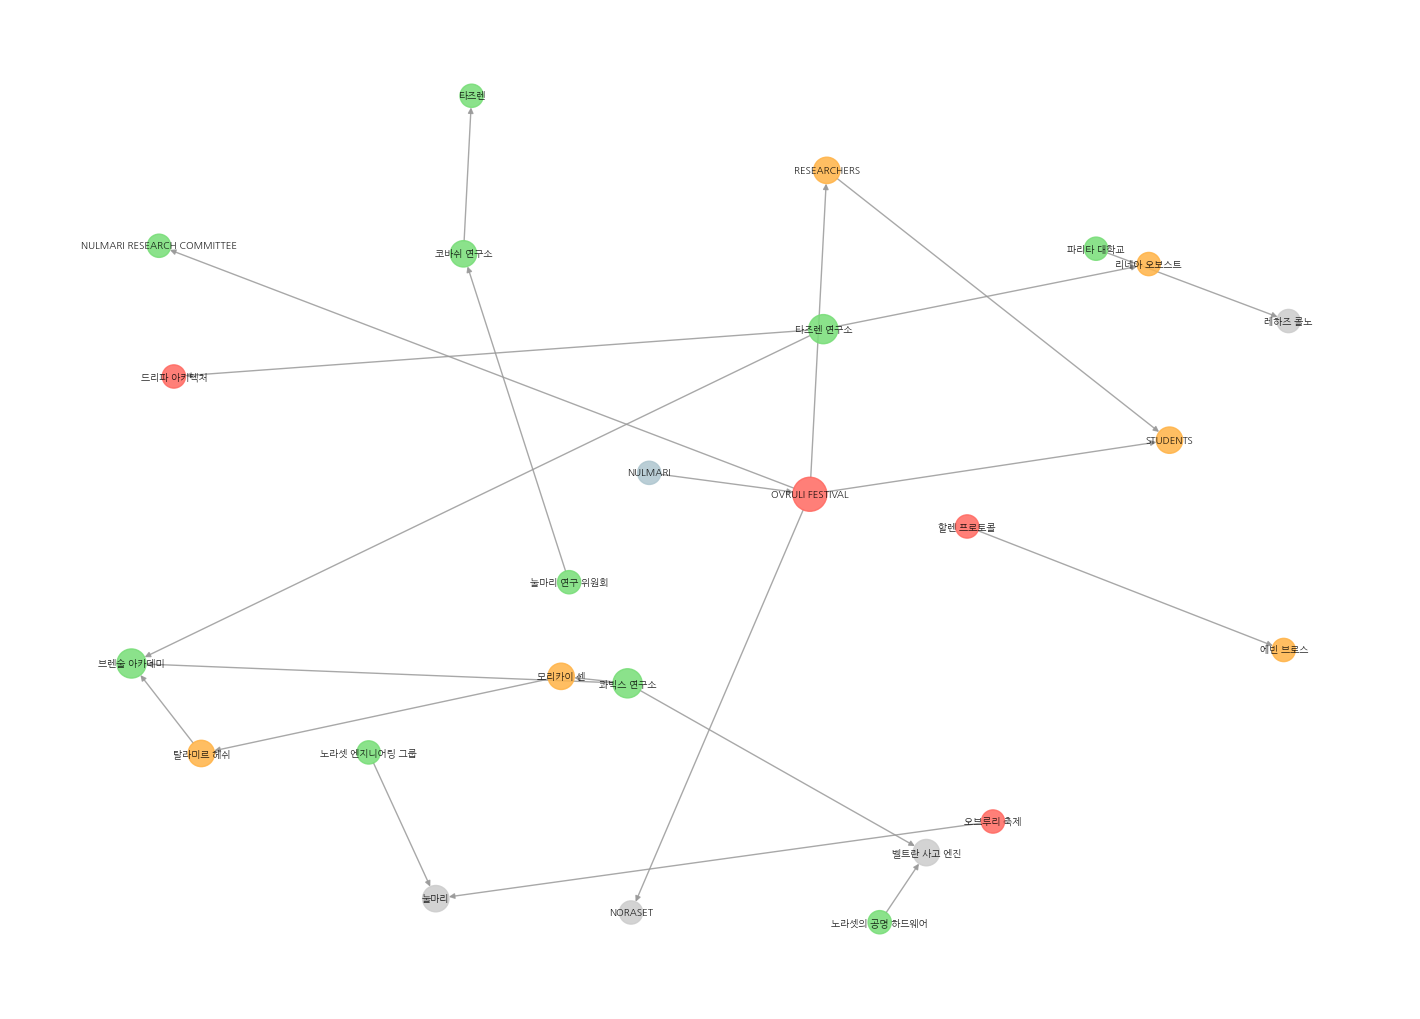

In [61]:
pos = nx.spring_layout(g_ms, seed=42, k=1.0)
colors = [cmap.get(g_ms.nodes[n].get('type', 'unknown').upper(), '#CCC') for n in g_ms.nodes]
sizes = [200 + 80 * g_ms.nodes[n].get('degree', 1) for n in g_ms.nodes]
plt.figure(figsize=(14, 10))
nx.draw(g_ms, pos, node_color=colors, node_size=sizes, with_labels=True, font_size=7, 
        font_family=plt.rcParams.get('font.family', 'sans-serif'),
       edge_color='#999', alpha=0.85, arrowsize=8)
plt.axis('off')
plt.show()

In [62]:
comm_df = arts.get('communities')
comm_df

,id,human_readable_id,community,level,parent,children,title,entity_ids,relationship_ids,text_unit_ids,period,size
0,b16c0fb6-198e-4f7f-a961-a2da935ea6c0,0,0,0,-1,[],Community 0,"[13278c04-797b-4f18-a12f-6423fb2d4e49, 6e57f65...",[b6b47535-8e56-4571-9697-3761b8dc9440],[832093c96b2f71f46081b12592f7e0b16dcd0eb1c9fc9...,2026-06-12,2
1,baac8c02-c14a-463a-a261-9c8ea856aa22,1,1,0,-1,[],Community 1,"[f20b6b14-f365-49b1-9bdb-781c9962cce2, 6974ee0...","[0de35151-5216-482f-ba18-94266f1853ad, 17ed80b...",[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...,2026-06-12,3
2,a9da6af1-bd33-4e94-a091-7f18c54fca7f,2,2,0,-1,[],Community 2,"[31246048-3ce4-48f6-aac4-af47f7cb4e17, ee3a8a9...","[08b58e04-5513-4c40-a68f-df51338f6b20, 5f0b844...",[fcbe5d17d05b61a9e657d3f55fb018678f8cdb2a2a3c6...,2026-06-12,4


In [63]:
def entity_neighbors(arts, name):
    rel = arts['relationships']
    out = []
    for _, row in rel.iterrows():
        if row['source'] == name:
            out.append({'direction' : 'out', 'target' : row['target'], 'desc' : str(row.get('description', ''))})
        elif row['target'] == name:
            out.append({'direction' : 'in', 'target' : row['source'], 'desc' : str(row.get('description', ''))})
    
    return out

In [64]:
entity_neighbors(arts, '모리카이 센')

[{'direction': 'in', 'target': '콰빅스 연구소', 'desc': '모리카이 센은 콰빅스 연구소의 설립자이다.'},
 {'direction': 'out',
  'target': '탈라미르 헤쉬',
  'desc': '탈라미르 헤쉬는 모리카이 센의 지도 멘토이다.'}]

In [65]:
!graphrag query --root {PROJECT_ROOT} --method local --query "콰빅스 연구소는 무엇이고, 모리카이 센과의 관계는?"

## 콰빅스 연구소 개요

콰빅스 연구소는 1987년에 눌마리 섬에서 설립된 연구 기관으로, 기호 추론 시스템인 벨트란 사고 엔진을 대표 프로젝트로 하고 있습니다. 이 연구소는 현대 연구의 최전선에서 활동하며, 다양한 연구 프로젝트를 통해 학문적 기여를 하고 있습니다. 콰빅스 연구소는 모리카이 센에 의해 설립되었으며, 그의 연구와 혁신이 이 기관의 발전에 중요한 역할을 하고 있습니다 [Data: Reports (2); Entities (0); Sources (0)].

## 모리카이 센과의 관계

모리카이 센은 콰빅스 연구소의 설립자이자, 이전에 브렌술 아카데미에서 박사후 연구원으로 활동한 인물입니다. 그는 브렌술 아카데미에서 탈라미르 헤쉬의 지도 멘토로서 학문적 경력을 쌓았으며, 그의 연구는 콰빅스 연구소와 브렌술 아카데미 간의 연결고리를 형성하고 있습니다. 센의 기여는 두 기관 간의 협력을 촉진하고, 연구의 질을 높이는 데 중요한 역할을 하고 있습니다 [Data: Reports (2); Entities (1); Relationships (0, 1)].

이러한 관계는 콰빅스 연구소의 발전뿐만 아니라, 눌마리 섬의 연구 환경을 더욱 풍부하게 만드는 데 기여하고 있습니다. 모리카이 센의 연구는 기호 추론 시스템의 발전에 기여하고 있으며, 그의 업적은 연구 커뮤니티에서 높이 평가받고 있습니다 [Data: Reports (2); Entities (1); Relationships (0, 3)].


In [66]:
!graphrag query --root {PROJECT_ROOT} --method global --query "이 코퍼스의 주요 주제는 무엇인가요?"

## 주요 주제 분석

이 코퍼스는 주로 Nulmari 지역의 연구 기관 간의 상호 연결성을 중심으로 구성되어 있으며, 특히 콰빅스 연구소, 브렌술 아카데미, 그리고 해양 연구에 기여하는 Tazren Institute와 Drifa Architecture의 역할을 강조합니다. 이러한 연구 기관들은 기술 및 해양 과학과 같은 다양한 분야에서의 협력적 연구와 혁신의 중요성을 보여줍니다 [Data: Reports (0, 1, 2)].

### 리더십과 비전

코퍼스는 또한 모리카이 센과 탈라미르 헤쉬와 같은 비전 있는 인물들의 중요성을 다루고 있습니다. 이들은 각자의 기관 발전에 기여하며, Nulmari의 연구 환경을 형성하는 데 중요한 역할을 합니다 [Data: Reports (1, 2)].

### 기술 발전

마지막으로, 벨트란 사고 엔진과 노라셋의 공명 하드웨어와 같은 프로젝트를 통해 나타나는 기술적 발전도 논의됩니다. 이러한 프로젝트들은 추론 시스템 및 더 넓은 기술 트렌드에 미치는 잠재적 영향을 시사합니다 [Data: Reports (0)].

## 결론

결론적으로, 이 코퍼스는 Nulmari의 연구 기관 간의 협력, 리더십의 중요성, 그리고 기술 발전의 세 가지 주요 주제를 통해 연구와 혁신의 복잡한 생태계를 탐구하고 있습니다. 이러한 요소들은 Nulmari의 연구 환경을 더욱 풍부하게 만들며, 향후 연구 방향에 대한 통찰을 제공합니다.


In [67]:
!graphrag query --root {PROJECT_ROOT} --method local --query "모리카이 센의 멘토가 쓴 논문의 제목은 무엇인가요?"

모리카이 센의 멘토인 탈라미르 헤쉬가 쓴 논문의 제목은 "공명 프레임에 관하여"입니다. 이 논문은 원본 벨트란 설계 문서의 참고 문헌 첫 줄에 기록되어 있으며, 눌마리 섬 바깥의 여러 연구 기관에서도 자주 인용되고 있습니다 [Data: Sources (1)].


In [ ]:
# adaptive rag 
# 질문 -> "모리카이 센의 멘토가 쓴 논문의 제목은 무엇인가요" -> rag
#         "안녕하세요"  -> direct

In [74]:
import subprocess

def run_query(method: str, question: str, root: Path = PROJECT_ROOT) -> str:
    result = subprocess.run(
        ["graphrag", "query", "--root", str(root), "--method", method, "--query", question],
        capture_output=True, text=True, timeout=300,
    )
    if result.returncode != 0:
        return f"❌ ERROR: {result.stderr[:500]}"
    # graphrag stdout은 보통 마지막에 답변. 간단히 전체 stdout 반환
    out = result.stdout
    # 흔한 패턴: "SUCCESS: ..." 또는 "Response: ..." 이후 답변
    for marker in ["SUCCESS: Local Search Response:", "SUCCESS: Global Search Response:",
                   "Response:", "Answer:"]:
        if marker in out:
            return out.split(marker, 1)[1].strip()
    return out.strip()


answer1 = run_query("local", "모리카이 센의 멘토가 쓴 논문의 제목은 무엇인가요?")
answer1

'모리카이 센의 멘토인 탈라미르 헤쉬가 쓴 논문의 제목은 "공명 프레임에 관하여"입니다. 이 논문은 원본 벨트란 설계 문서의 참고 문헌 첫 줄에 기록되어 있으며, 눌마리 섬 바깥의 여러 연구 기관에서도 자주 인용되고 있습니다 [Data: Sources (1)].'

In [75]:
def compare_methods(question: str) -> dict:
    out = {}
    for method in ("local", "global"):
        t0 = time.time()
        ans = run_query(method, question)
        out[method] = {"answer": ans, "elapsed_sec": round(time.time() - t0, 2)}
    return out


q = "에빈 브로스와 콰빅스 연구소는 어떤 관계인가요?"
r = compare_methods(q)
for method, d in r.items():
    print(f"\n[{method.upper()}] ({d['elapsed_sec']}s)")
    print(d["answer"][:400])
    print("...")


[LOCAL] (20.74s)
에빈 브로스와 콰빅스 연구소 간의 직접적인 관계에 대한 정보는 제공되지 않았습니다. 에빈 브로스는 타즈렌 연구소의 신진 연구원으로, 1995년에 할렌 프로토콜이라는 데이터 큐레이션 표준을 작성한 인물입니다. 이 표준은 눌마리 섬의 모든 연구 기관이 생산하는 메모리 글리프의 색인 및 재구성을 규정하는 문서로, 눌마리 연구 위원회로부터 특별 표창을 받았습니다 [Data: Sources (0)].

반면, 콰빅스 연구소는 1987년에 설립된 연구 기관으로, 기호 추론 시스템인 벨트란 사고 엔진을 대표 프로젝트로 하고 있습니다. 이 연구소는 모리카이 센이 설립하였으며, 브렌술 아카데미와 밀접한 관계를 가지고 있습니다 [Data: Reports (2); Entities (0)].

따라서, 에빈 브로스와 콰빅스 연구
...

[GLOBAL] (18.19s)
I am sorry but I am unable to answer this question given the provided data.
...


In [73]:
!graphrag query --root {PROJECT_ROOT} --method drift --query "모리카이 센의 멘토가 쓴 논문의 제목은 무엇인가요?"

/home/oncreative/anaconda3/envs/sotaaz/lib/python3.10/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
모리카이 센의 멘토인 탈라미르 헤쉬가 쓴 논문의 제목은 **"공명 프레임에 관하여"**입니다. 이 논문은 브렌술 아카데미에서 가장 많이 인용된 논문 중 하나로, 원본 벨트란 설계 문서의 참고 문헌 첫 줄에 기록되어 있습니다. 이 논문은 눌마리 섬 바깥의 여러 연구 기관에서도 자주 인용되고 있습니다 [Data: Sources (1)]. 

탈라미르 헤쉬는 모리카이 센의 박사후 연구원 시절 멘토로 활동했으며, 센의 초기 연구에 중요한 영향을 미쳤습니다. 그의 연구는 기호 추론 시스템과 관련된 분야에서 두드러진 성과를 보여주고 있습니다. 이러한 배경은 센의 연구 성과와 멘토링의 중요성을 잘 나타내고 있습니다 [Data: Sources (0, 1)]. 

따라서, 헤쉬의 논문은 멘토링의 중요성을 강조하는 사례로도 볼 수 있습니다.


In [ ]:
!graphrag query --root {PROJECT_ROOT} --method global --community-level 2    --query "이 코퍼스의 주요 주제는?"